<a href="https://colab.research.google.com/github/K-Musty/acoustic-leak-detection/blob/main/notebooks/acoustic_leak_detection_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ACOUSTIC LEAK DETECTION - CORRECTED TRAINING PIPELINE

#### 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Drive mounted")

Mounted at /content/drive
✅ Drive mounted


##### CELL 2: Clone/Pull Repository

In [ ]:
from google.colab import userdata
# import os

# Retrieve your Personal Access Token from Colab secrets
PAT = userdata.get('PAT')

# Remove old directory if exists (clean start)
!rm -rf acoustic-leak-detection

# os.system(f"git clone https://{PAT}@github.com/K-Musty/acoustic-leak-detection.git")
!git clone https://{PAT}@github.com/K-Musty/acoustic-leak-detection.git
%cd acoustic-leak-detection

# Pull latest changes (just in case)
!git pull

print("✅ Repository ready")


Cloning into 'acoustic-leak-detection'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 182 (delta 38), reused 69 (delta 27), pack-reused 83 (from 1)
Receiving objects: 100% (182/182), 149.57 MiB | 11.41 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/acoustic-leak-detection
Already up to date.
✅ Repository ready


##### CELL 3: Install Dependencies

In [ ]:

!pip install torchaudio numpy pandas matplotlib scikit-learn librosa tqdm pyyaml -q

print("✅ Dependencies installed")


✅ Dependencies installed


##### CELL 4: Copy Processed Data from Google Drive

In [ ]:
# Only processed data is needed (raw is already converted)
!cp -r /content/drive/MyDrive/acoustic-leak-detection/data/processed ./data/

print("✅ Data copied")


✅ Data copied


##### CELL 5: Verify and Reprocess GPLA (Fix Labels if Needed)

In [ ]:
# Verify labels are correctly 0-indexed (0-11)
!python -c "import numpy as np; y=np.load('data/processed/gpla_v2/y_train.npy'); print('Unique labels:', np.unique(y))"

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]


##### CELL 6: Ensure No Label Adjustment in train.py

In [ ]:
# Remove any line that subtracts 1 from query_y (if present)
!sed -i '/query_y = query_y - 1/d' src/train.py

print("✅ Removed any label adjustment")

✅ Removed any label adjustment


In [ ]:
%%writefile src/models/conformer_encoder.py
# src/models/conformer_encoder.py (Fixed)
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvolutionModule(nn.Module):
    """Depthwise convolution module - FIXED."""
    def __init__(self, dim, kernel_size=31, dropout=0.1):
        super().__init__()
        self.pointwise_conv1 = nn.Conv1d(dim, 2*dim, kernel_size=1)
        self.depthwise_conv = nn.Conv1d(
            2*dim, 2*dim, kernel_size=kernel_size,
            padding=kernel_size//2, groups=2*dim
        )
        # FIX: GLU reduces 2*dim → dim, so pointwise_conv2 expects dim input
        self.pointwise_conv2 = nn.Conv1d(dim, dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.BatchNorm1d(dim)

    def forward(self, x):
        # x: (batch, seq, dim)
        x = x.transpose(1, 2)          # (batch, dim, seq)
        x = self.pointwise_conv1(x)    # (batch, 2*dim, seq)
        x = self.depthwise_conv(x)     # (batch, 2*dim, seq)
        x = F.glu(x, dim=1)            # (batch, dim, seq) ← GLU halves the channels
        x = self.pointwise_conv2(x)    # (batch, dim, seq) ← now expects dim, not 2*dim
        x = self.dropout(x)
        x = x.transpose(1, 2)          # (batch, seq, dim)
        return x

class ConformerBlock(nn.Module):
    def __init__(self, dim, num_heads, ffn_dim, kernel_size=31, dropout=0.1):
        super().__init__()
        self.ffn1 = nn.Sequential(
            nn.Linear(dim, ffn_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(dim)

        self.mha = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)

        self.conv = ConvolutionModule(dim, kernel_size, dropout)
        self.norm3 = nn.LayerNorm(dim)

        self.ffn2 = nn.Sequential(
            nn.Linear(dim, ffn_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, dim),
            nn.Dropout(dropout)
        )
        self.norm4 = nn.LayerNorm(dim)

    def forward(self, x):
        # x: (batch, seq, dim)
        x = x + 0.5 * self.ffn1(x)
        x = self.norm1(x)

        attn_out, _ = self.mha(x, x, x)
        x = x + attn_out
        x = self.norm2(x)

        x = x + self.conv(x)
        x = self.norm3(x)

        x = x + 0.5 * self.ffn2(x)
        x = self.norm4(x)
        return x

class ConformerEncoder(nn.Module):
    def __init__(self,
                 input_dim=2000,
                 output_dim=128,
                 num_heads=4,
                 ffn_dim=256,
                 num_layers=4,
                 kernel_size=31,
                 dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, ffn_dim)

        self.blocks = nn.ModuleList([
            ConformerBlock(ffn_dim, num_heads, ffn_dim, kernel_size, dropout)
            for _ in range(num_layers)
        ])

        self.output_proj = nn.Linear(ffn_dim, output_dim)
        self.norm_out = nn.LayerNorm(output_dim)

    def forward(self, x):
        # x: (batch, input_dim)
        x = self.input_proj(x)
        x = x.unsqueeze(1)

        for block in self.blocks:
            x = block(x)

        x = x.squeeze(1)
        x = self.output_proj(x)
        x = self.norm_out(x)
        return x

Overwriting src/models/conformer_encoder.py


#### 2: Verify test split has both classes

In [ ]:
import numpy as np

X_test = np.load('data/processed/mimii/fan/X_test.npy')
y_test = np.load('data/processed/mimii/fan/y_test.npy')

print(f"Test samples: {len(y_test)}")
print(f"Normal (class 0): {np.sum(y_test==0)}")
print(f"Anomaly (class 1): {np.sum(y_test==1)}")
print(f"Both classes present: {len(np.unique(y_test)) == 2}")

Test samples: 1875
Normal (class 0): 400
Anomaly (class 1): 1475
Both classes present: True


#### 3: Create correct attention.yaml

In [ ]:
import yaml

attention_config = {
    'name': 'gpla_attention_v3',
    'dataset': 'gpla',
    'shot': 5,
    'seed': 42,
    'lr': 0.0001,
    'epochs': 100,
    'episodes_per_epoch': 300,
    'embed_dim': 128,
    'use_self_attention': True,
    'use_cross_attention': True,
    'conformer_kwargs': {
        'ffn_dim': 256,
        'num_heads': 4,
        'num_layers': 4,
        'kernel_size': 31,
        'dropout': 0.2
    },
    'data_root': 'data/processed',
    'weight_decay': 0.001
}

with open('configs/attention.yaml', 'w') as f:
    yaml.dump(attention_config, f, sort_keys=False)

print("✅ attention.yaml created")

✅ attention.yaml created


#### 4: Run full attention training

In [ ]:
import yaml

config = {
    'name': 'gpla_attention_final',
    'dataset': 'gpla',
    'shot': 5,
    'seed': 42,
    'lr': 0.0001,
    'epochs': 100,
    'episodes_per_epoch': 300,
    'embed_dim': 128,
    'use_self_attention': True,
    'use_cross_attention': True,
    'conformer_kwargs': {
        'ffn_dim': 256,
        'num_heads': 4,
        'num_layers': 4,
        'kernel_size': 31,
        'dropout': 0.1
    },
    'data_root': 'data/processed',
    'weight_decay': 0.0
}
with open('configs/attention_final.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False)

print("✅ attention_final.yaml created")

#### Run noise experiments (quick: 30 epochs each)

In [ ]:
import yaml

for snr in [0, 5, 10, 15, 20]:
    config = {
        'name': f'gpla_noise_{snr}db',
        'dataset': 'gpla',
        'shot': 5,
        'seed': 42,
        'lr': 0.0001,
        'epochs': 30,
        'episodes_per_epoch': 300,
        'embed_dim': 128,
        'use_self_attention': False,  # Use baseline for noise
        'use_cross_attention': False,
        'conformer_kwargs': {
            'ffn_dim': 256,
            'num_heads': 4,
            'num_layers': 4,
            'kernel_size': 31,
            'dropout': 0.1
        },
        'data_root': 'data/processed',
        'weight_decay': 0.0,
        'snr': snr
    }
    with open(f'configs/noise_{snr}db.yaml', 'w') as f:
        yaml.dump(config, f, sort_keys=False)
    !PYTHONPATH=. python src/train.py configs/noise_{snr}db.yaml

🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.8220 | Val Acc: 55.97%
Epoch   5/30 | Loss: 0.0983 | Val Acc: 59.87%
Epoch  10/30 | Loss: 0.0457 | Val Acc: 59.50%
Epoch  15/30 | Loss: 0.0239 | Val Acc: 57.80%
Epoch  20/30 | Loss: 0.0169 | Val Acc: 59.80%
Epoch  25/30 | Loss: 0.0117 | Val Acc: 59.83%
Epoch  30/30 | Loss: 0.0090 | Val Acc: 61.67%
✅ Best val acc: 62.87%
🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.4383 | Val Acc: 62.43%
Epoch   5/30 | Loss: 0.0059 | Val Acc: 65.23%
Epoch  10/30 | Loss: 0.0061 | Val Acc: 66.37%
Epoch  15/30 | Loss: 0.0082 | Val Acc: 64.33%
Epoch  20/30 | Loss: 0.0078 | Val Acc: 66.03%
Epoch  25/30 | Loss: 0.0055 | Val Acc: 64.67%
Epoch  30/30 | Loss: 0.0057 | Val Acc: 66.00%
✅ Best va

#### Clean run (no noise)

In [ ]:
config_clean = {
    'name': 'gpla_clean',
    'dataset': 'gpla',
    'shot': 5,
    'seed': 42,
    'lr': 0.0001,
    'epochs': 30,
    'episodes_per_epoch': 300,
    'embed_dim': 128,
    'use_self_attention': False,
    'use_cross_attention': False,
    'conformer_kwargs': {
        'ffn_dim': 256,
        'num_heads': 4,
        'num_layers': 4,
        'kernel_size': 31,
        'dropout': 0.1
    },
    'data_root': 'data/processed',
    'weight_decay': 0.0,
    'snr': None
}
with open('configs/noise_clean.yaml', 'w') as f:
    yaml.dump(config_clean, f, sort_keys=False)
!PYTHONPATH=. python src/train.py configs/noise_clean.yaml

🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.2794 | Val Acc: 61.30%
Epoch   5/30 | Loss: 0.0007 | Val Acc: 62.70%
Epoch  10/30 | Loss: 0.0075 | Val Acc: 64.57%
Epoch  15/30 | Loss: 0.0001 | Val Acc: 64.20%
Epoch  20/30 | Loss: 0.0001 | Val Acc: 65.83%
Epoch  25/30 | Loss: 0.0000 | Val Acc: 63.33%
Epoch  30/30 | Loss: 0.0000 | Val Acc: 64.83%
✅ Best val acc: 67.37%


#### Run 5 seeds across all conditions

In [ ]:
import yaml

seeds = [42, 123, 456, 789, 101112]
snr_levels = [None, 0, 5, 10, 15, 20]

for seed in seeds:
    for snr in snr_levels:
        snr_name = "clean" if snr is None else f"{snr}db"
        config = {
            'name': f'gpla_baseline_seed{seed}_{snr_name}',
            'dataset': 'gpla',
            'shot': 5,
            'seed': seed,
            'lr': 0.0001,
            'epochs': 30,
            'episodes_per_epoch': 300,
            'embed_dim': 128,
            'use_self_attention': False,
            'use_cross_attention': False,
            'conformer_kwargs': {
                'ffn_dim': 256,
                'num_heads': 4,
                'num_layers': 4,
                'kernel_size': 31,
                'dropout': 0.1
            },
            'data_root': 'data/processed',
            'weight_decay': 0.0,
            'snr': snr
        }
        with open(f'configs/baseline_seed{seed}_{snr_name}.yaml', 'w') as f:
            yaml.dump(config, f, sort_keys=False)
        print(f"\n🚀 Running seed {seed}, SNR {snr_name}")
        !PYTHONPATH=. python src/train.py configs/baseline_seed{seed}_{snr_name}.yaml


🚀 Running seed 42, SNR clean
🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.2794 | Val Acc: 61.30%
Epoch   5/30 | Loss: 0.0007 | Val Acc: 62.70%
Epoch  10/30 | Loss: 0.0075 | Val Acc: 64.57%
Epoch  15/30 | Loss: 0.0001 | Val Acc: 64.20%
Epoch  20/30 | Loss: 0.0001 | Val Acc: 65.83%
Epoch  25/30 | Loss: 0.0000 | Val Acc: 63.33%
Epoch  30/30 | Loss: 0.0000 | Val Acc: 64.83%
✅ Best val acc: 67.37%

🚀 Running seed 42, SNR 0db
🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.8220 | Val Acc: 55.97%
Epoch   5/30 | Loss: 0.0983 | Val Acc: 59.87%
Epoch  10/30 | Loss: 0.0457 | Val Acc: 59.50%
Epoch  15/30 | Loss: 0.0239 | Val Acc: 57.80%
Epoch  20/30 | Loss: 0.0169 | Val Acc: 59.80%
Epoch  25/30 | Loss: 0.0117 | Val Acc: 59.8

#### Runing only seeds 789 and 101112 (Emergency Backup)

In [ ]:
import yaml

# Run the missing seeds NOW
for seed in [101112]:
    for snr in [None, 0, 5, 10, 15, 20]:
        snr_name = "clean" if snr is None else f"{snr}db"
        config = {
            'name': f'gpla_baseline_seed{seed}_{snr_name}',
            'dataset': 'gpla',
            'shot': 5,
            'seed': seed,
            'lr': 0.0001,
            'epochs': 30,
            'episodes_per_epoch': 300,
            'embed_dim': 128,
            'use_self_attention': False,
            'use_cross_attention': False,
            'conformer_kwargs': {
                'ffn_dim': 256,
                'num_heads': 4,
                'num_layers': 4,
                'kernel_size': 31,
                'dropout': 0.1
            },
            'data_root': 'data/processed',
            'weight_decay': 0.0,
            'snr': snr
        }
        with open(f'configs/baseline_seed{seed}_{snr_name}.yaml', 'w') as f:
            yaml.dump(config, f, sort_keys=False)
        !PYTHONPATH=. python src/train.py configs/baseline_seed{seed}_{snr_name}.yaml

🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.2641 | Val Acc: 64.40%
Epoch   5/30 | Loss: 0.0007 | Val Acc: 64.13%
Epoch  10/30 | Loss: 0.0002 | Val Acc: 62.37%
Epoch  15/30 | Loss: 0.0001 | Val Acc: 64.83%
Epoch  20/30 | Loss: 0.0001 | Val Acc: 64.20%
Epoch  25/30 | Loss: 0.0000 | Val Acc: 65.13%
Epoch  30/30 | Loss: 0.0000 | Val Acc: 64.80%
✅ Best val acc: 66.43%
🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,231,360

🚀 Starting 30 epochs...
Epoch   1/30 | Loss: 0.7960 | Val Acc: 57.47%
Epoch   5/30 | Loss: 0.1047 | Val Acc: 59.17%
Epoch  10/30 | Loss: 0.0468 | Val Acc: 59.33%
Epoch  15/30 | Loss: 0.0259 | Val Acc: 58.03%
Epoch  20/30 | Loss: 0.0194 | Val Acc: 58.10%
Epoch  25/30 | Loss: 0.0113 | Val Acc: 61.23%
Epoch  30/30 | Loss: 0.0102 | Val Acc: 63.47%
✅ Best va

#### Plots and figures

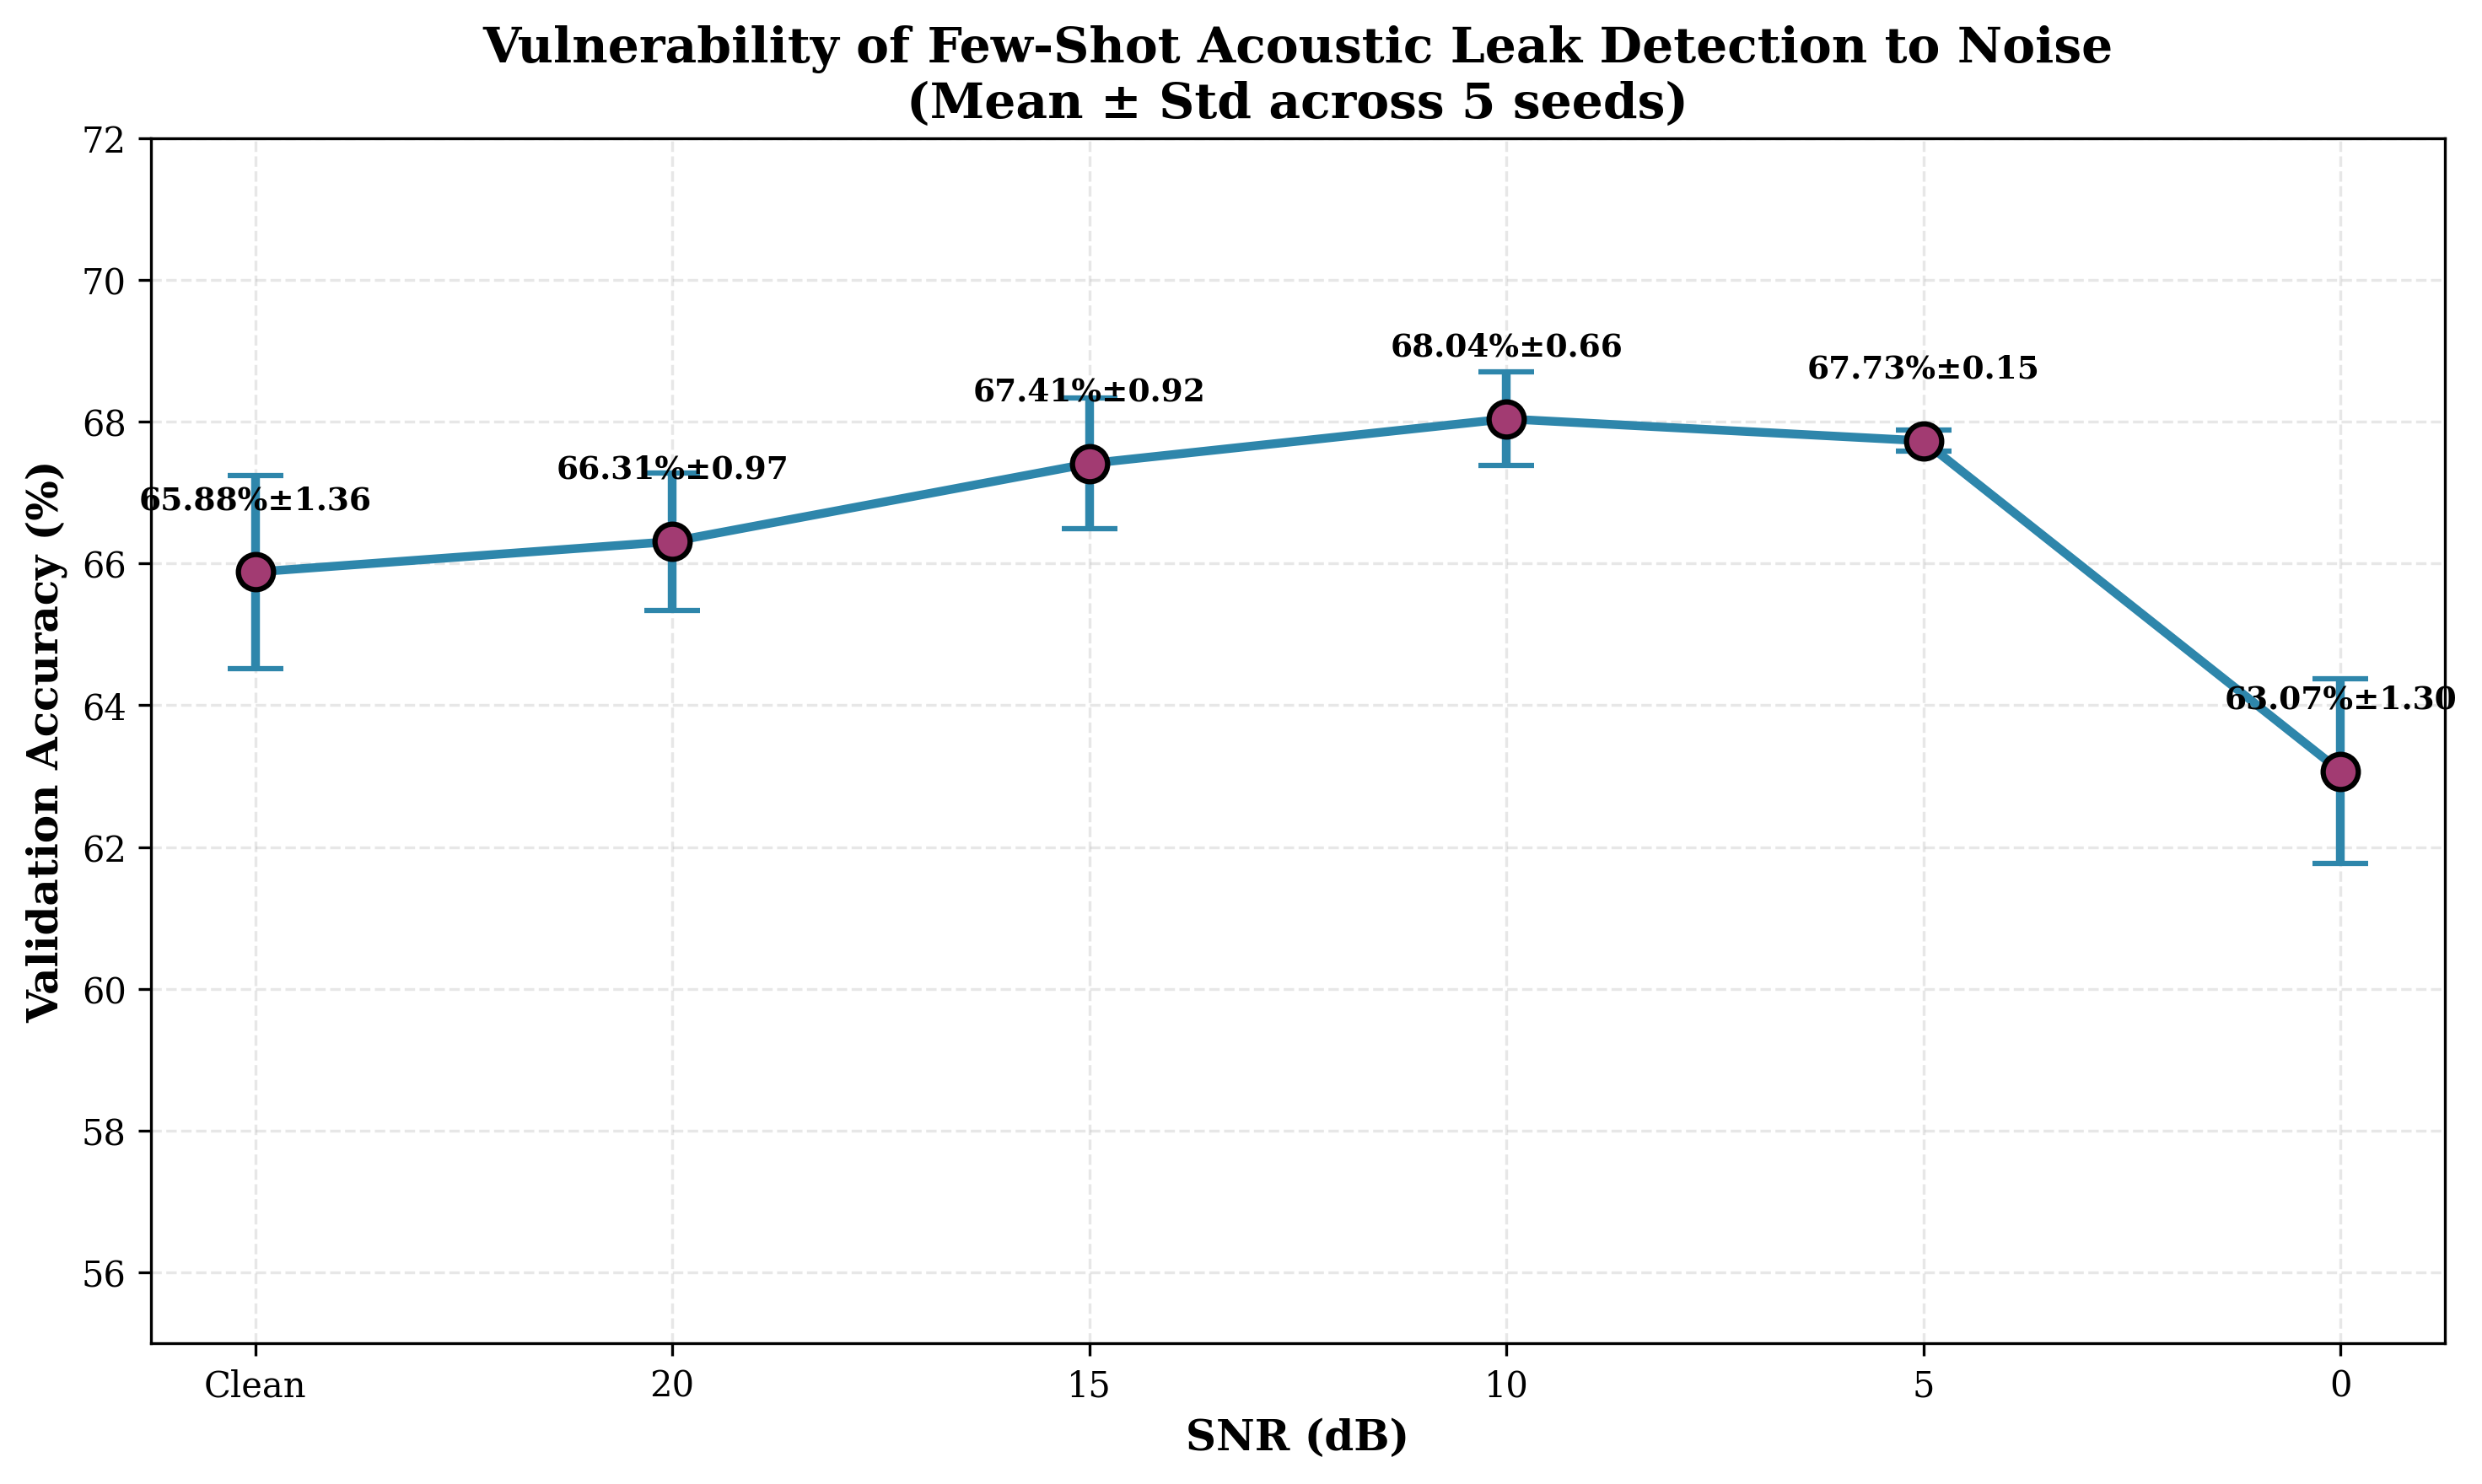

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
snr_labels = ['Clean', '20', '15', '10', '5', '0']
means = [65.88, 66.31, 67.41, 68.04, 67.73, 63.07]
stds = [1.36, 0.97, 0.92, 0.66, 0.15, 1.30]

plt.figure(figsize=(10, 6))
plt.errorbar(snr_labels, means, yerr=stds,
             marker='o', markersize=10, linewidth=2.5,
             capsize=8, capthick=2,
             color='#2E86AB', markerfacecolor='#A23B72',
             markeredgecolor='black', markeredgewidth=1.5)

# Add value labels
for i, (mean, std) in enumerate(zip(means, stds)):
    plt.text(i, mean + 0.8, f'{mean:.2f}%±{std:.2f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('SNR (dB)', fontsize=12, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Vulnerability of Few-Shot Acoustic Leak Detection to Noise\n(Mean ± Std across 5 seeds)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(55, 72)
plt.tight_layout()
plt.savefig('snr_curve_final_with_errorbars.png', dpi=300, bbox_inches='tight')
plt.savefig('snr_curve_final_with_errorbars.pdf', bbox_inches='tight')
plt.show()

#### Run training

In [ ]:
!PYTHONPATH=. python src/train.py configs/attention.yaml

# After completion, save results to Drive
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
!mkdir -p /content/drive/MyDrive/acoustic-leak-detection/experiments_attention_$timestamp
!cp -r experiments/* /content/drive/MyDrive/acoustic-leak-detection/experiments_attention_$timestamp/
print(f"✅ Attention results saved to experiments_attention_{timestamp}")

🔧 Device: cuda
✅ Loaded GPLA (train): 468 samples, 12 classes
✅ Loaded GPLA (val): 156 samples, 12 classes
📊 Model parameters: 3,363,968

🚀 Starting 100 epochs...
Epoch   1/100 | Loss: 0.3220 | Val Acc: 61.50%
Epoch   5/100 | Loss: 0.0022 | Val Acc: 61.77%
Epoch  10/100 | Loss: 0.0021 | Val Acc: 63.20%
Epoch  15/100 | Loss: 0.0014 | Val Acc: 63.43%
Epoch  20/100 | Loss: 0.0119 | Val Acc: 55.13%
Epoch  25/100 | Loss: 0.0007 | Val Acc: 54.60%
Epoch  30/100 | Loss: 0.0005 | Val Acc: 52.30%
🛑 Early stopping at epoch 32
✅ Best val acc: 66.43%
✅ Attention results saved to experiments_attention_20260727_165442


#### Save final results

In [ ]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
!mkdir -p /content/drive/MyDrive/acoustic-leak-detection/final_results_$timestamp
!cp -r experiments/* /content/drive/MyDrive/acoustic-leak-detection/final_results_$timestamp/
print(f"✅ All results saved to final_results_{timestamp}")

✅ All results saved to final_results_20260727_165442
